<a href="https://colab.research.google.com/github/mohadesehsotoudehnia/AI-home-works/blob/main/miniProject2%20/%20MP2_Part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Q1***


Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Definition of Muculloch Pitts neuron

In [ ]:
class McCulloch_Pitts_neuron():
    def __init__(self, weights, threshold):
        self.weights = weights
        self.threshold = threshold

    def model(self, x):
        if self.weights @ x >= self.threshold:
            return 1
        else:
            return 0

Function to check the interior of triangle ABC

In [ ]:
def Area(x, y):
    #  y >= 0 → w = [0, 1], threshold = 0
    neur1 = McCulloch_Pitts_neuron([0, 1], 0)

    #  y <= 2x - 2 → 2x - y - 2 >= 0 → w = [2, -1], threshold = 2
    neur2 = McCulloch_Pitts_neuron([2, -1], 2)

    #  y <= -2x + 6 → -2x - y + 6 >= 0 → w = [-2, -1], threshold = -6
    neur3 = McCulloch_Pitts_neuron([-2, -1], -6)

    # Output of each condition
    z1 = neur1.model(np.array([x, y]))
    z2 = neur2.model(np.array([x, y]))
    z3 = neur3.model(np.array([x, y]))

    # Final neuron (AND Neuron)
    neur_final = McCulloch_Pitts_neuron([1, 1, 1], 3)
    z_final = neur_final.model(np.array([z1, z2, z3]))

    return [z_final]

Generate 2000 random points in the desired range

In [ ]:
num_points = 2000
x_values = np.random.uniform(0, 4, num_points)
y_values = np.random.uniform(-1, 3, num_points)

Using Area function

In [ ]:

# Lists of points based on neuron output

red_points = []
green_points = []

# Checking any point with the Area function
for i in range(num_points):
    z = Area(x_values[i], y_values[i])
    if z == [1]:
        green_points.append((x_values[i], y_values[i]))
    else:
        red_points.append((x_values[i], y_values[i]))

# Separating x and y values ​​for plotting
red_x, red_y = zip(*red_points)
green_x, green_y = zip(*green_points)


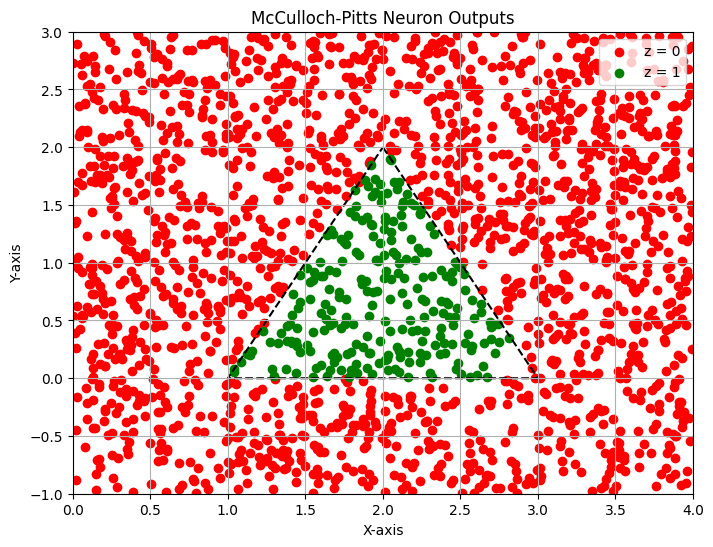

In [ ]:
# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(red_x, red_y, color='red', label='z = 0')
plt.scatter(green_x, green_y, color='green', label='z = 1')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('McCulloch-Pitts Neuron Outputs')

# Drawing the sides of triangle ABC
A, B, C = (2, 2), (3, 0), (1, 0)
triangle = plt.Polygon([A, B, C], fill=False, edgecolor='black', linestyle='--', linewidth=1.5)
plt.gca().add_patch(triangle)

# Axis range
plt.xlim(0, 4)
plt.ylim(-1, 3)
plt.grid(True)
plt.legend(loc='upper right')
plt.savefig('triangle_output.png', bbox_inches='tight')
plt.show()